In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import yfinance as yf

# Finance 
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import plotting
import matplotlib.pyplot as plt
import pandas as pd
from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage



from IPython.display import display, Markdown
# Custom
from utils import PortfolioEvaluator
from backtest import Backtest

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor


import yfinance as yf

# plotting
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.patches as mpatches
from IPython.display import display, Markdown

from typing import Tuple
from utils import ForecastingMetrics, TradingMetrics
from backtest import Backtest

import warnings

import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import het_arch
from arch import arch_model

# Finance 
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import plotting
import matplotlib.pyplot as plt
import pandas as pd
from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage
from statsmodels.tsa.api import VAR

# ml
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA

# Custom
from utils import PortfolioEvaluator
from backtest import Backtest

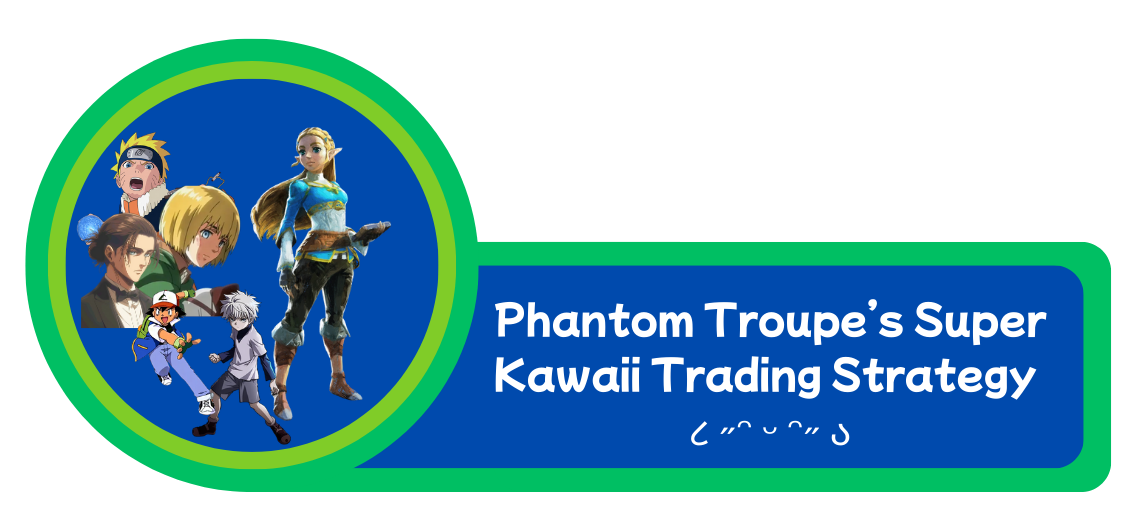

# I. Executive Summary

# II. Introduction

We are participating in White Stone’s annual forecasting and trading challenge. For this competition, the core difficulty lies in the fact that an accurate forecasting model does not automatically guarantee a profitable trading strategy. Because of this, the competition evaluates competitors on two separate dimensions. Namely, they are forecasting accuracy and portfolio profitability. 

With these constraints, we identify the main problem of the case as a to how we can accurately forecast and then use those forecasts to build a portfolio and trading strategy that maximizes profits? To tackle this, we outline three objectives:

Portfolio Construction and Capital Allocation: To determine how our team should allocate the starting capital of $10,000 across selected stocks.
Forecasting Model Development: To design a forecasting model that maximizes predictive accuracy for 60-day price movements using only Yahoo Finance data.
Strategy Design for Profit Maximization: To convert forecasts into a systematic trading strategy that is profitable during backtesting.

Based on these objectives, we ask the following guiding questions:
1. **Portfolio Construction and Capital Allocation:**
    - What is the most appropriate way to allocate our $10,000 starting capital?
2. **Forecasting Model Development**
    - Which forecasting model is likely to achieve the highest accuracy for our 60-day prediction task?
    - Which accuracy metrics (RMSE, MAPE, directional accuracy, or a combination) should we rely on?
3. **Strategy Design for Profit Maximization**
    - How can we transform our forecasts into a systematic and profitable trading strategy that performs well during backtesting?
    - Does our strategy generate consistent profits across the randomly selected post–January 2025 60-day periods?


# III. Super Kawaii Trading Strategy Overview

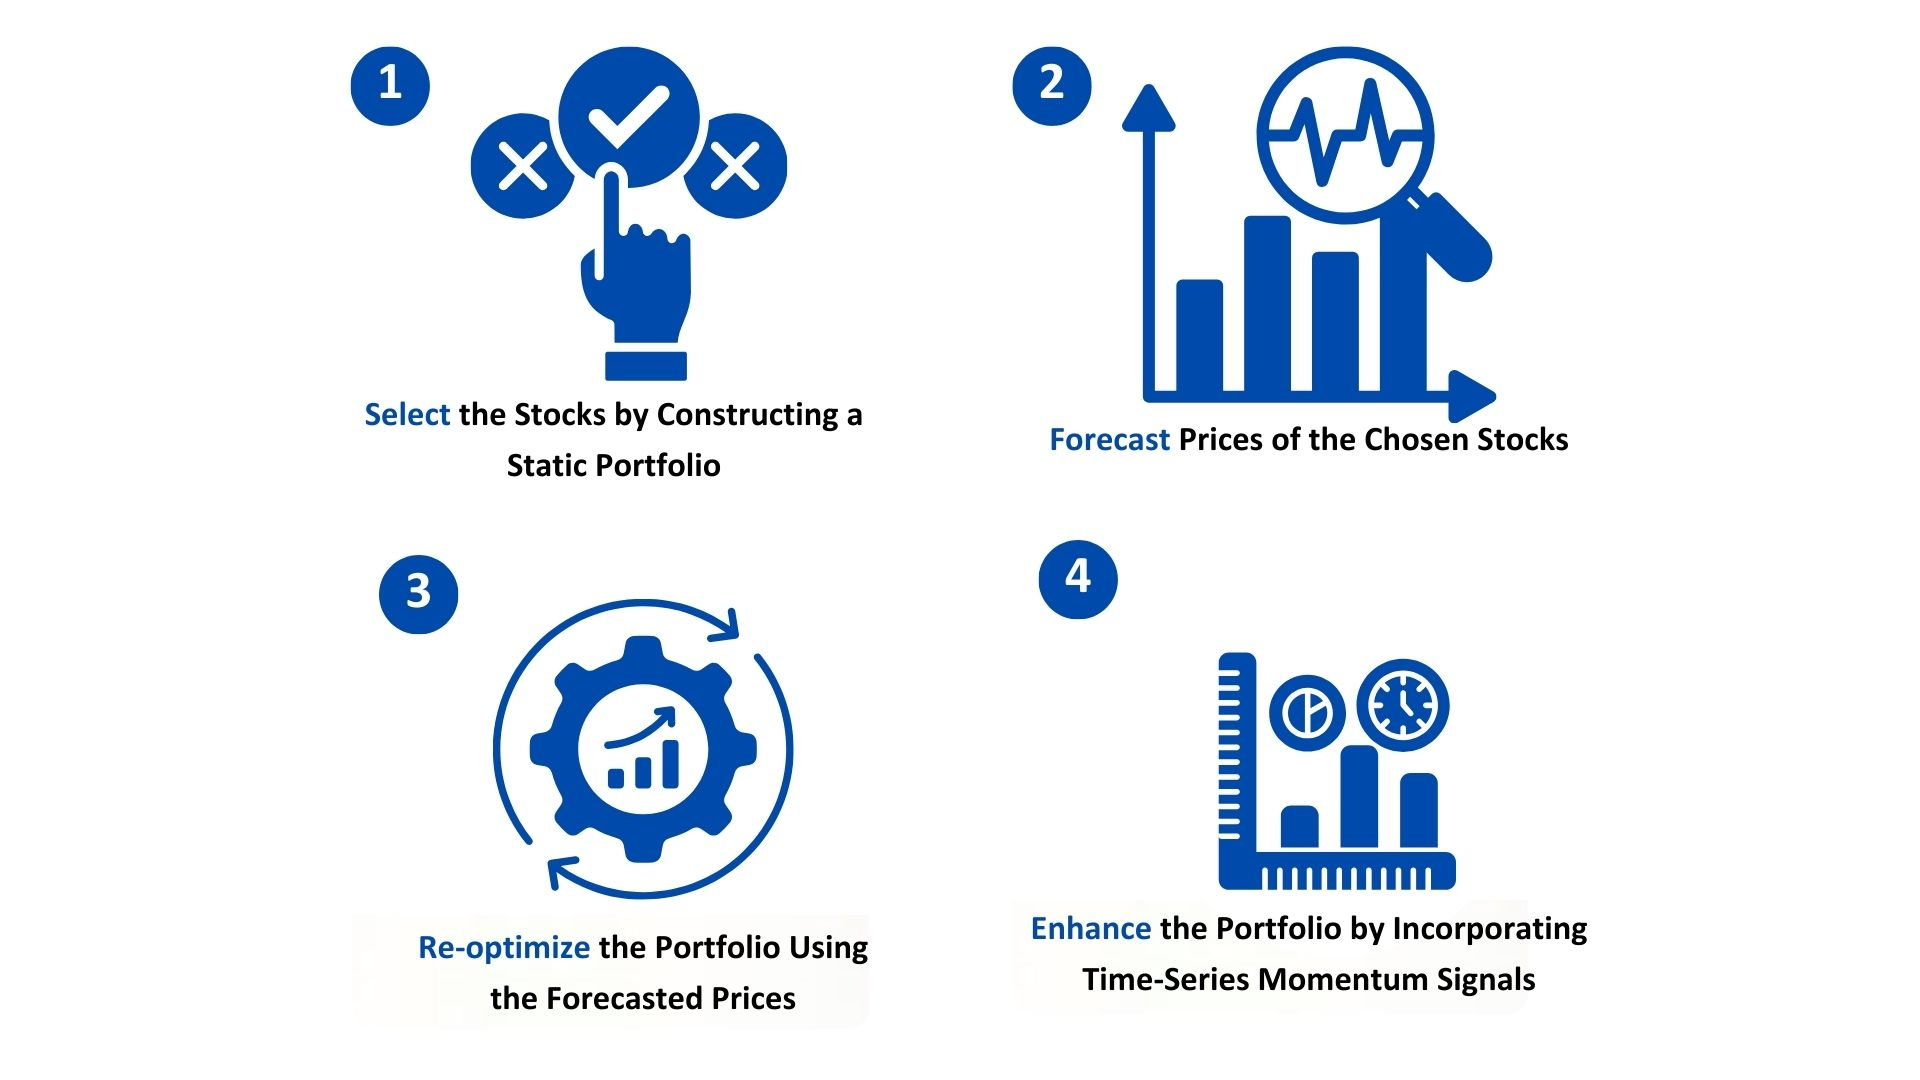

**Figure 1.** Super Kawaii Trading Strategy Overview

For the trading strategy, we hold these as key assumptions based on the trading competition. First, we are provided with $10,000 in starting capital, a transaction cost of 0.1%, and a risk-free rate of 2%. Second, all data must be sourced exclusively from Yahoo Finance, and the training period is limited to January 1, 2022 to January 1, 2025. After this period, each team must generate a 60-day stock price forecast for a randomly assigned 60-day window. Finally, profitability will be assessed through backtesting on that unseen period.

From here, we select the stocks by constructing a static portfolio. We optimize this static portfolio using a Markowitz mean–variance framework, relying on historical returns within the training window to estimate expected returns and the covariance matrix. This provides an initial long-only allocation that balances return and risk, forming the baseline portfolio from which the rest of the strategy builds.

Next, we forecast the prices using a range of econometric and machine learning models. These include Random Walk with Drift, VAR, Ridge Regression, Linear Regression, Naive models, ARIMA and ARIMA-GARCH, Random Forest, Gradient Boosting, XGBoost, and Seasonal Naive approaches. Across these models, we compute forecast accuracy metrics such as MAE, MSE, RMSE, MAPE, SMAPE, and directional accuracy. The table of results shows clear performance variation, with more complex machine learning models generally producing lower forecast errors than simpler statistical baselines.

After producing the 60-day forecasts, we re-optimize the portfolio using these predicted returns. In this step, the Markowitz framework is run a second time, but the expected returns are replaced with our model-based forecasts. This creates a forward-looking allocation that incorporates the directional information contained in the forecasting models.

We then refine the allocation by integrating time-series momentum signals. For each stock, we measure recent return trends using a 63-day (3-month) window and tilt the weights toward assets with sustained positive momentum. 


# IV. Select the Stocks by Constructing a Static Portfolio

In selecting stocks, we utilize Modern Portfolio Theory (MPT) as developed by Harry Markowitz. We acted as rational investors wherein we wanted to minimize risk while maximizing returns. As such let us formally set up MPT where we will be using the steps as provided by Ślusarczyk and Ślepaczuk (2025). The key idea is that a rational investor with a fixed amount of capital (such as 1000 USD in our case) should distribute that capital across different stocks in a way that maximizes expected return while minimizing risk.


We represent this distribution using a weight vector $w$, where each component corresponds to the fraction of capital invested in one of the thirty given stocks:
$$
w =
\begin{bmatrix}
w_{1}\\
\vdots \\
w_{30}
\end{bmatrix},
$$


Moreover, the weights are constrained by their having to add up to one, so $\sum_{i=1}^{30} w_i = 1$. Also, we restrict the analysis to long-only portfolios by imposing $w_i \geq 0$ for any stock $i$ since the portfolio evaluator is designed only for long positions.
As such, we now formally set up MPT where we will be using the steps as provided by Ślusarczyk and Ślepaczuk (2025) and PyPortfolioOpt, the python module that we are using to get the weights of MPT. Let $r$ be a matrix of T historical daily log returns of n stocks:


Let $r$ be a matrix of T historical daily log returns of n stocks:


$$
r =
\begin{bmatrix}
r_{t-1,1} & \cdots & r_{t-1,n} \\
\vdots & \ddots & \vdots \\
r_{t-T,1} & \cdots & r_{t-T,n}
\end{bmatrix},
$$


where: 
- $T$ is the number of days, so $T=752$ 
- $n$ is number of stocks, so $n$=30
- $r_{t,n}$ is the historical log return for the $n$-th stock for day $t$


Then $\hat{\mu}$ is a vector of means of annualized expected log return:


$$
\hat{\mu} =
\begin{bmatrix}
\hat{\mu}_1 \\
\vdots \\
\hat{\mu}_n
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{T} \sum_{i=1}^{T} r_{t-i,1} \\
\vdots \\
\frac{1}{T} \sum_{i=1}^{T} r_{t-i,n}
\end{bmatrix},
$$


and $\hat{\Sigma}$ is the variance-covariance matrix of annualized expected log return:


$$
\hat{\Sigma} =
\begin{bmatrix}
\hat{\sigma}_1^2 & \cdots & \hat{\sigma}_{1,n} \\
\vdots & \ddots & \vdots \\
\hat{\sigma}_{1,n} & \cdots & \hat{\sigma}_n^2
\end{bmatrix},
$$


where $\hat{\sigma}_i^2$ is the empirical variance of historical log returns of the $i$-th stock and $\hat{\sigma}_{i,j}$ is the empirical covariance between historical log returns of the $i$-th and $j$-th stock. These quantities form the sample covariance matrix, which is subsequently passed through the Ledoit–Wolf shrinkage estimator (implemented via `ledoit_wolf`) to obtain a more stable, regularized covariance matrix for portfolio optimization as plotted below in Figure 2.


As shown in Figure 2, the covariances between the stocks are generally small as indicated by the predominantly blue-colored (so near-zero) covariance matrix. This feature is central to Modern Portfolio Theory since it enables portfolio diversification. By selecting stocks that are relatively uncorrelated with one another, we can reduce overall portfolio risk while maintaining expected returns.


In [52]:
stocks = [
    # Tech
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA",
    # Finance
    "JPM", "BAC", "WFC", "C", "GS", "MS",
    # Consumer Goods
    "KO", "PG", "PEP", "WMT", "COST", "CL",
    # Energy
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC",
    # ETF
    "SPY", "QQQ", "DIA", "IWM", "VTI"
]

# ChatGPT made this dictionary
stock_categories = {
    "AAPL": "Technology", "MSFT": "Technology", "NVDA": "Technology",
    "AMZN": "Technology", "GOOGL": "Technology", "META": "Technology", "TSLA": "Technology",
    "JPM": "Finance", "BAC": "Finance", "WFC": "Finance", "C": "Finance", "GS": "Finance", "MS": "Finance",
    "KO": "Consumer Goods", "PG": "Consumer Goods", "PEP": "Consumer Goods",
    "WMT": "Consumer Goods", "COST": "Consumer Goods",
    "CL": "Consumer Goods", "XOM": "Energy", "CVX": "Energy", "COP": "Energy",
    "SLB": "Energy", "EOG": "Energy", "MPC": "Energy",
    "SPY": "ETF", "QQQ": "ETF", "DIA": "ETF", "IWM": "ETF", "VTI": "ETF"
}

# Get the inverse of stock_categories
category_stock = {}
for stock, category in stock_categories.items():
    if category not in category_stock:
        category_stock[category] = []
    category_stock[category].append(stock)
    
# Define date range
start = "2022-01-01"
end = "2025-01-01"

# Download historical data
close_historical_df = yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"]
close_historical_df.head(2)

[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,AMZN,BAC,C,CL,COP,COST,CVX,DIA,EOG,...,PEP,PG,QQQ,SLB,SPY,TSLA,VTI,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,178.270309,170.404495,41.931015,54.393017,76.912796,63.700027,540.298645,101.482445,341.154022,75.843269,...,154.084122,147.359756,392.184082,29.220690,453.210388,399.926666,230.069702,45.828430,45.85870,55.125225
2022-01-04,176.007767,167.522003,43.574478,54.815403,77.167397,66.463211,537.934143,103.328972,343.197205,79.329262,...,154.306793,147.875412,387.097260,30.639349,453.058624,383.196655,229.634140,47.653252,45.01857,57.198711


**Figure 2.** Covariance of Daily Log Returns Across Stocks

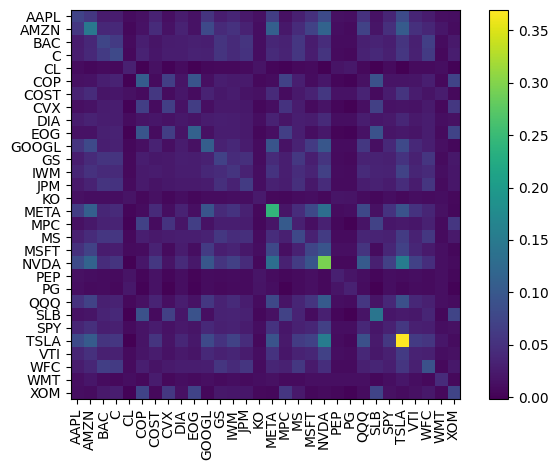

In [53]:
# mu and Sigma are annualized
mu = mean_historical_return(close_historical_df, log_returns=True)
Sigma = CovarianceShrinkage(close_historical_df, log_returns=True).ledoit_wolf()

plotting.plot_covariance(Sigma)
display(Markdown('**Figure 2.** Covariance of Daily Log Returns Across Stocks'))

From here, we try to maximize the Sharpe Ratio, which is defined as the ratio of the portfolio’s excess return over the risk-free rate to its total risk (standard deviation of returns):
$$\text{Sharpe Ratio} = \frac{\mathbb{E}[R_p] - R_f}{\sigma_p}$$


where $\mathbb{E}[R_p]$ is the expected return of the portfolio, $R_f$ is the risk-free rate, and $\sigma_p$ is the portfolio volatility. The weight vector that achieves the highest Sharpe Ratio is called the tangency portfolio, which  provides the best balance between risk and return. In other words, it gives the most return for each unit of risk taken.


As illustrated in Figure 3, distributing capital across multiple stocks is advantageous because it allows us to exploit the small covariances between assets, thereby reducing overall portfolio risk while maintaining attractive returns. Conversely, investing all capital in a single stock is generally suboptimal because it places the portfolio in the southeast region of the risk-return space, characterized by higher volatility and lower risk-adjusted returns. By diversifying, we effectively move closer to the top-left region of the frontier, where risk is minimized for a given level of expected return.


Figure 3 also highlights the advantage of the tangency portfolio over a simple equal-weighted portfolio. While both portfolios may have similar volatility, the tangency portfolio achieves a noticeably higher return, demonstrating the benefit of optimizing weights rather than allocating equally.


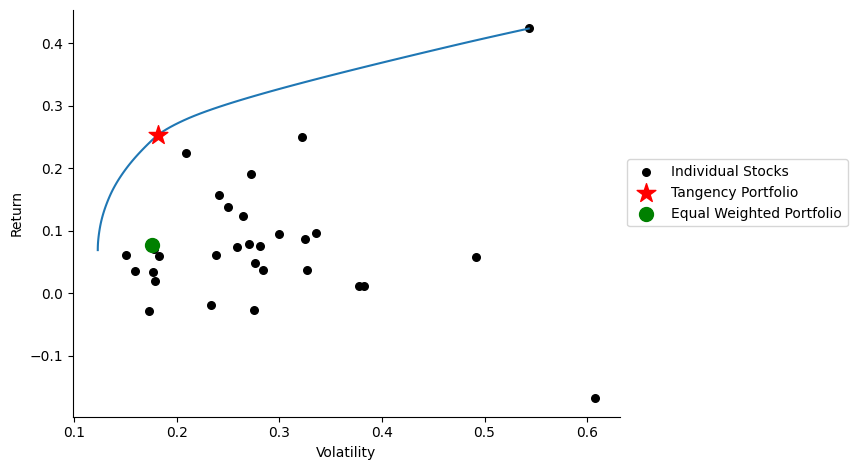

**Figure 3.** Scatterplot of Portfolio Volatility vs Expected Return

In [54]:
# Compute tangency portfolio
ef_tan = EfficientFrontier(mu, Sigma)
tangency_portfolio = ef_tan.max_sharpe(risk_free_rate=0.02)
weights_df = pd.DataFrame(
    [(stock, weight) for stock, weight in ef_tan.clean_weights().items() if weight > 0],
    columns=['Stock', 'Weight']
)

exp_return, vol, sharpe = ef_tan.portfolio_performance(risk_free_rate=0.02)

# Create another EF instance just for plotting
ef_plot = EfficientFrontier(mu, Sigma)
plotting.plot_efficient_frontier(ef_plot, show_assets=True)
plt.scatter(vol, exp_return, marker="*", color="r", s=200, label="Tangency Portfolio", zorder=10)

# plot the equal weighted portfolio
num_stocks = close_historical_df.shape[1]
equal_weight = np.ones(num_stocks) / num_stocks
mu_equal = mu @ equal_weight
sigma_equal = np.sqrt(equal_weight.T @ Sigma @ equal_weight)

plt.scatter(sigma_equal, mu_equal, marker='o', color='green', s=100, label='Equal Weighted Portfolio')
handles, labels = plt.gca().get_legend_handles_labels()
labels = ['Individual Stocks', 'Tangency Portfolio', 'Equal Weighted Portfolio']

plt.legend(handles[1:], labels, loc='upper left', bbox_to_anchor=(1, 0.65))


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

display(Markdown('**Figure 3.** Scatterplot of Portfolio Volatility vs Expected Return'))

From Table 1, we observe that the tangency portfolio assigns the largest weight to Walmart (WMT), followed by NVIDIA (NVDA), Marathon Petroleum (MPC), and ExxonMobil (XOM). It is notable that these stocks come from different sectors, which aligns with the principle of diversification. For instance, movements in the Energy sector are less likely to be strongly correlated with those in Technology or Consumer Goods, and vice versa. This cross-sector allocation helps reduce overall portfolio risk while maintaining attractive expected returns.


In [55]:
weights_df['Sector'] = weights_df['Stock'].map(stock_categories)
display(weights_df[['Stock', 'Sector', 'Weight']])
display(Markdown('**Table 1.** Stock and Allocated Weight in the Tangency Portfolio'))

,Stock,Sector,Weight
0,MPC,Energy,0.14690
1,NVDA,Technology,0.14750
2,WMT,Consumer Goods,0.56538
3,XOM,Energy,0.14021


**Table 1.** Stock and Allocated Weight in the Tangency Portfolio

# V. Forecast Log Prices

## a. Baselines

From Figure 4, raw prices across the 30 stocks are highly variable and generally exhibit a strong upward trend. Thus, we applied a log transformation to stabilize the variance and allow for easier comparison across stocks. Additionally, since our framework relies on log returns, applying the log transformation is consistent with our methodology and ensures the returns are appropriately scaled for subsequent analysis.

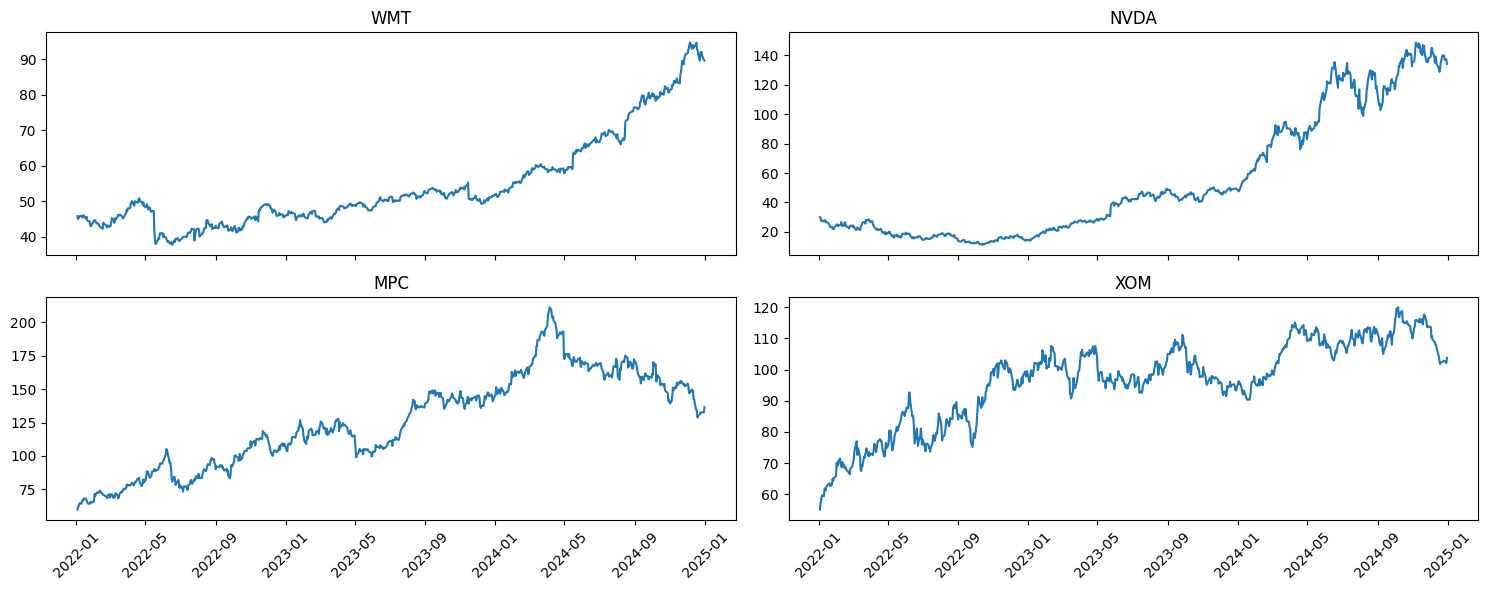

**Figure 4.** USD Prices of the 4 Stocks

In [6]:
selected_stocks = ["WMT", "NVDA", "MPC", "XOM"]
close_historical_df = close_historical_df[selected_stocks]

fig, axs = plt.subplots(2, 2, figsize=(15, 6), sharex=True)

for ax, stock in zip(axs.flatten(), close_historical_df.columns):
    ax.plot(close_historical_df[stock])
    ax.set_title(stock)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

display(Markdown("**Figure 4.** USD Prices of the 4 Stocks"))

In [7]:
# Keep only the stocks with non-zero weights
selected_stocks = ["WMT", "NVDA", "MPC", "XOM"]
close_historical_df = close_historical_df[selected_stocks]

To construct the baseline models (mean, naive, and seasonal naive) in a single figure, we first assessed whether seasonality was present across the stocks. As shown in Figure 5, there is no consistent or systematic seasonal pattern observable across the full set of assets. Given this inconsistency, we proceed by assuming a simplified seasonality of 20 business days (a month) for the baseline seasonal naive model.

We also implement a three-way data split into training, validation, and test sets, covering the period from January 2022 to January 2025, using a 70–20–10 split. For modeling purposes, we predict log prices, as our framework relies on PyPortfolioOpt functions such as `mean_historical_return` and `CovarianceShrinkage`, which require the actual price data. Therefore, after generating the log price forecasts, we can simply exponentiate the results to recover the prices in their original scale.

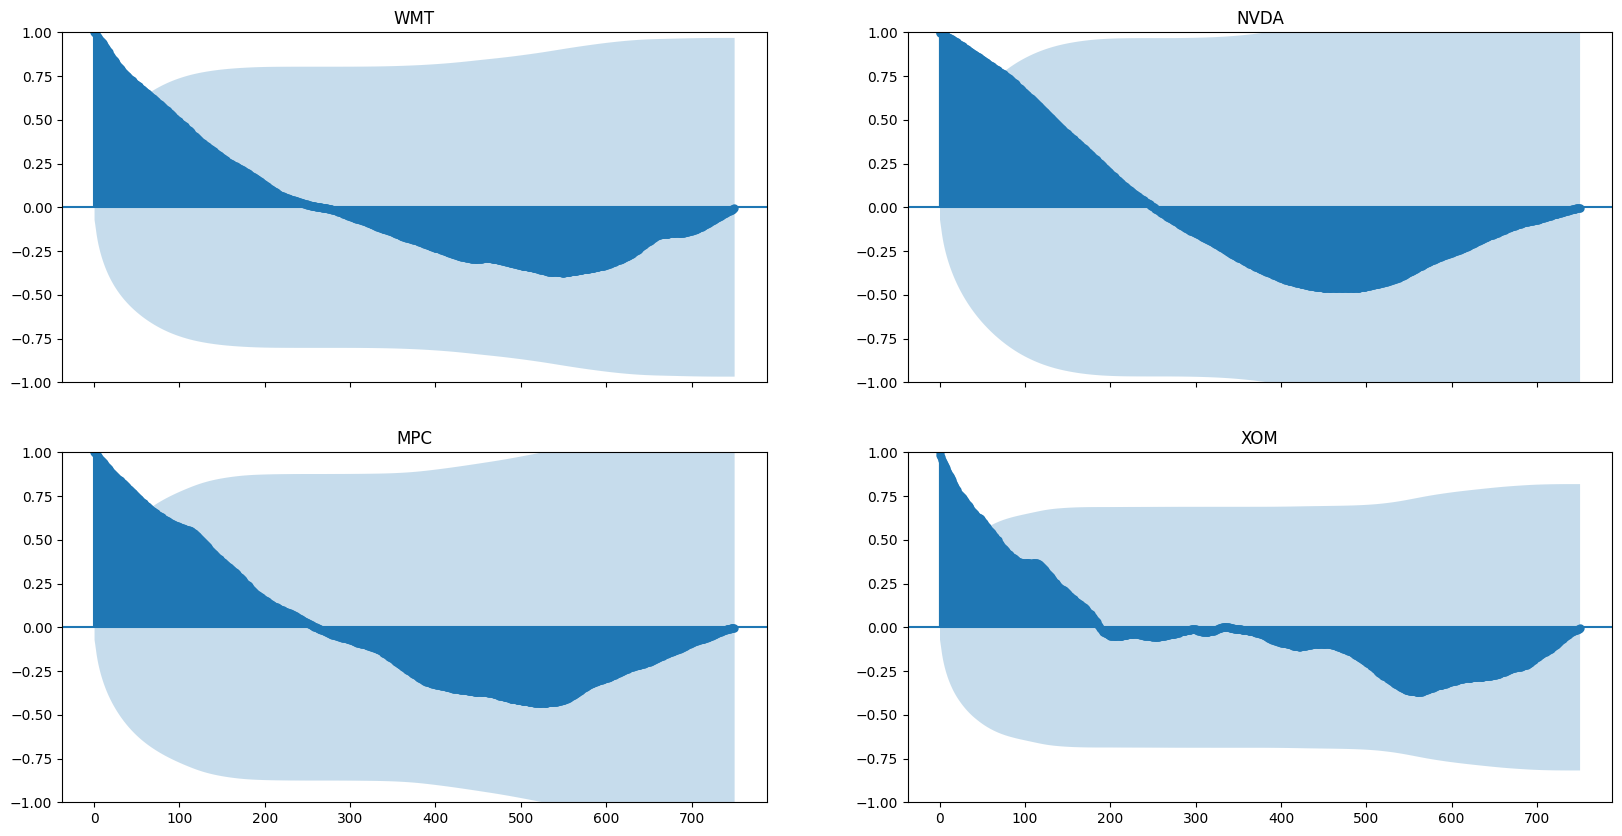

**Figure 5.** ACF of the 4 Stocks

In [12]:
# Apply log
close_log_df = np.log(close_historical_df)

fig, axs = plt.subplots(2, 2, figsize=(20, 10), sharex=True)

for ax, stock in zip(axs.flatten(), close_log_df.columns):
    plot_acf(close_log_df[stock], ax=ax, lags=750, title=stock)

plt.show()

display(Markdown("**Figure 5.** ACF of the 4 Stocks"))

In [13]:
# Total number of rows
n = close_log_df.shape[0]

# Compute split points
train_end = int(n * 0.7)           # 70% for training
val_end = train_end + int(n * 0.2) # next 20% for validation

# Create splits
train_df = close_log_df.iloc[:train_end]
val_df = close_log_df.iloc[train_end:val_end]
test_df = close_log_df.iloc[val_end:]

print(f"Training set: {train_df.shape[0]} rows ({train_df.shape[0]/n:.0%})")
print(f"Validation set: {val_df.shape[0]} rows ({val_df.shape[0]/n:.0%})")
print(f"Test set: {test_df.shape[0]} rows ({test_df.shape[0]/n:.0%})")


Training set: 527 rows (70%)
Validation set: 150 rows (20%)
Test set: 76 rows (10%)


In [14]:
def forecast_seasonal_naive(df: pd.DataFrame, m: int = 5, horizon: int = None) -> pd.DataFrame:
    """
    Seasonal naïve forecasting model applied column-wise to a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame where each column represents a univariate time series
        (e.g., multiple stock price series).
    m : int, optional (default=5)
        The assumed seasonality length. The model uses the last `m` observations
        of each column as the repeating seasonal pattern.
    horizon : int, optional
        Number of future time steps to forecast. If None, uses length of df.

    Returns
    -------
    pd.DataFrame
        A DataFrame containing seasonal naïve forecasts for each column of `df`.
        Each column contains `horizon` forecasts derived from the last `m` values.
    """
    if horizon is None:
        horizon = len(df)

    forecasts = {}
    for col in df.columns:
        last_m_vals = df[col].iloc[-m:].values.ravel()
        repeated_vals = np.tile(last_m_vals, horizon)[:horizon]
        forecasts[col] = repeated_vals

    return pd.DataFrame(forecasts)


In [15]:
horizon = val_df.shape[0]  # number of rows to forecast

# Mean forecast
mean_forecast = pd.DataFrame([train_df.mean().values] * horizon,
                             index=val_df.index,
                             columns=val_df.columns)

# Naive forecast (last value)
naive_forecast = pd.DataFrame([train_df.iloc[-1].values] * horizon,
                              index=val_df.index,
                              columns=val_df.columns)

# Seasonal naive forecast
seasonal_naive_forecast = forecast_seasonal_naive(train_df, m=20, horizon=horizon)
seasonal_naive_forecast.index = val_df.index


From Figure 6, we plotted all four stocks with reduced opacity and highlighted the mean to facilitate easier visualization. Among the three baseline models, the naive forecast performs best on the validation set, capturing the general movement of the log prices more accurately than the mean or seasonal naive forecasts.

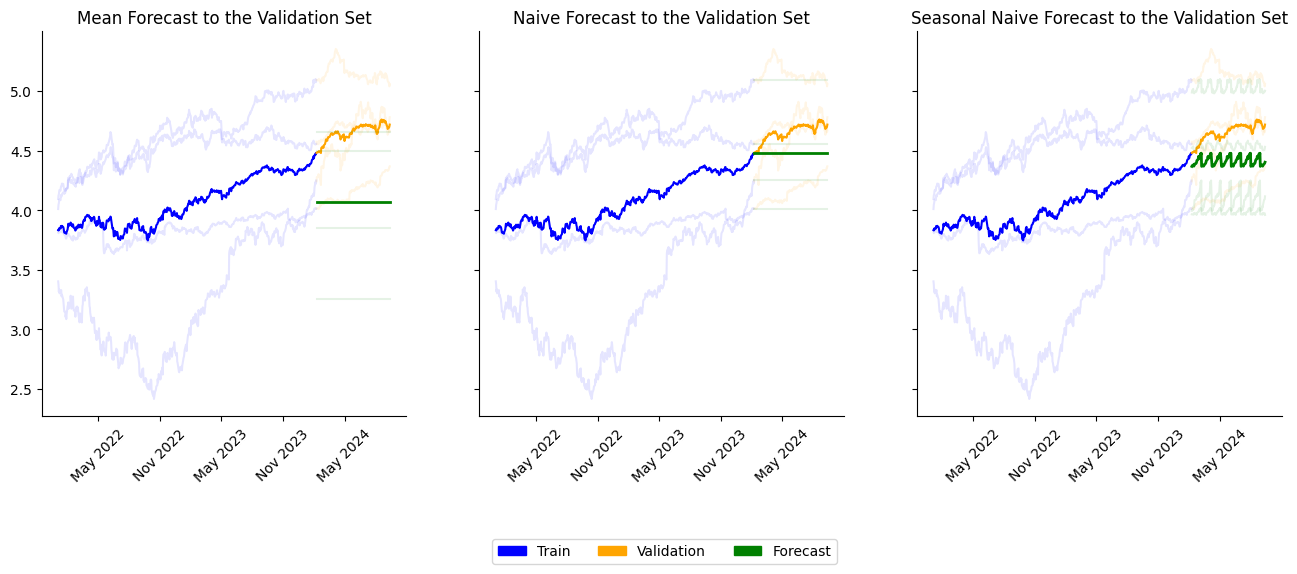

**Figure 6.** Baseline Forecasts of Log Prices Across Stocks

In [17]:
# Drawing time!
fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

opacity_num = 0.1
for ax in axs:
    ax.plot(train_df, color='blue', alpha=opacity_num)
    ax.plot(train_df.mean(axis=1), color='blue')

    ax.plot(val_df, color='orange', alpha=opacity_num)
    ax.plot(val_df.mean(axis=1), color='orange', label='Val Median')

# Plot the mean
axs[0].plot(mean_forecast, label='Mean Forecast', color='green', alpha=opacity_num)
axs[0].plot(mean_forecast.mean(axis=1), label='Mean Forecast', linewidth=2, color='green')
axs[0].set_title('Mean Forecast to the Validation Set')

# plot the naive
axs[1].plot(naive_forecast, label='Naive Forecast', color='green', alpha=opacity_num)
axs[1].plot(naive_forecast.mean(axis=1), label='Naive Forecast', linewidth=2, color='green')
axs[1].set_title('Naive Forecast to the Validation Set')

# plot the Seasonal Naive
axs[2].plot(seasonal_naive_forecast, label='Seasonal Naive Forecast', color='green', alpha=opacity_num)
axs[2].plot(seasonal_naive_forecast.mean(axis=1), label='Seasonal Naive Forecast', linewidth=2, color='green')
axs[2].set_title('Seasonal Naive Forecast to the Validation Set')

# Prettier x-axis
for ax in axs:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # major ticks each month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # format as 'Jan 2025'
    ax.tick_params(axis='x', rotation=45)  # rotate labels
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# Add patches legend at the bottom for dataset colors
train_patch = mpatches.Patch(color='blue', label='Train')
val_patch = mpatches.Patch(color='orange', label='Validation')
forecast_patch = mpatches.Patch(color='green', label='Forecast')

plt.legend(handles=[train_patch, val_patch, forecast_patch], loc='best', bbox_to_anchor=(-0.2, -0.3), ncol=3)

plt.show()

display(Markdown("**Figure 6.** Baseline Forecasts of Log Prices Across Stocks"))


In [18]:
# Dictionary to store all metrics
performance_stock = {}

for stock in val_df.columns:
    # Compute metrics for each baseline
    performance_stock[stock] = {
        'Mean': ForecastingMetrics.compute_all_metrics(val_df[stock], mean_forecast[stock]),
        'Naive': ForecastingMetrics.compute_all_metrics(val_df[stock], naive_forecast[stock]),
        'Seasonal Naive': ForecastingMetrics.compute_all_metrics(val_df[stock], seasonal_naive_forecast[stock])
    }

In [19]:
def performance_dict_to_df(performance_stock_dict):
    """
    Converts a nested dictionary of performance metrics into a multi-index DataFrame.
    
    Parameters
    ----------
    performance_stock_dict : dict
        Nested dict of the form {stock: {model_name: {metric_name: value, ...}, ...}, ...}
    
    Returns
    -------
    pd.DataFrame
        MultiIndex DataFrame with index ['Stock', 'Model'] and metric columns.
    """
    df_list = []

    for stock, metrics_per_model in performance_stock_dict.items():
        for model, metrics in metrics_per_model.items():
            row = metrics.copy()
            row['Stock'] = stock
            row['Model'] = model
            df_list.append(row)
    
    metrics_df = pd.DataFrame(df_list).set_index(['Stock', 'Model'])
    return metrics_df

#performance_dict_to_df(performance_stock)


## b. ARIMA

The first step in constructing an ARIMA model is to assess the stationarity of the log price time series using the Augmented Dickey-Fuller (ADF) and Kwiatkowski-Phillips-Schmidt-Shin (KPSS) tests. We applied both tests across all stocks, recording the results in Table 2. For the four stocks, none of them passed both tests, so they were considered non-stationary and were thus differenced to get the stock's log returns.

In [21]:
warnings.filterwarnings("ignore")

# --- ADF Test Function ---
def adf_test_suite(timeseries):
    """
    Performs the Augmented Dickey-Fuller test on a time series.
    H0: The series is non-stationary.
    """
    # Use 'ct' for constant and trend since visual inspection (Figure 2) shows a clear trend
    result = adfuller(timeseries, autolag='AIC', regression='ct')
    
    p_value = result[1]
    
    # Check p-value against a 5% significance level (alpha=0.05)
    is_stationary = 'Stationary' if p_value <= 0.05 else 'Non-Stationary'
    
    return pd.Series({
        'ADF Statistic': result[0],
        'ADF P-value': p_value,
        'ADF Lags Used': result[2],
        'ADF Conclusion (alpha=0.05)': is_stationary
    })

# --- KPSS Test Function ---
def kpss_test_suite(timeseries):
    """
    Performs the Kwiatkowski-Phillips-Schmidt-Shin test on a time series.
    H0: The series is trend-stationary.
    """
    # Use 'ct' for trend-stationarity (constant and trend)
    result = kpss(timeseries, regression='ct', nlags='auto')
    
    p_value = result[1]
    
    # Check p-value against a 5% significance level (alpha=0.05)
    is_stationary = 'Stationary' if p_value > 0.05 else 'Non-Stationary'
    
    return pd.Series({
        'KPSS Statistic': result[0],
        'KPSS P-value': p_value,
        'KPSS Lags Used': result[2],
        'KPSS Conclusion (alpha=0.05)': is_stationary
    })

In [22]:
adf_results_df = close_log_df.apply(adf_test_suite, axis=0).T
kpss_results_df = close_log_df.apply(kpss_test_suite, axis=0).T

final_results = pd.DataFrame({
    'ADF Conclusion': adf_results_df['ADF Conclusion (alpha=0.05)'],
    'KPSS Conclusion': kpss_results_df['KPSS Conclusion (alpha=0.05)']
})

def consolidate_conclusion(row):
    """Consolidate stationarity conclusions from ADF and KPSS tests for a time series."""
    adf_c = row['ADF Conclusion']
    kpss_c = row['KPSS Conclusion']
    
    if adf_c == 'Stationary' and kpss_c == 'Stationary':
        return 'Strictly Stationary (Strong Evidence)'
    elif adf_c == 'Non-Stationary' and kpss_c == 'Non-Stationary':
        return 'Non-Stationary (Strong Evidence)'
    elif adf_c == 'Stationary' and kpss_c == 'Non-Stationary':
        # ADF rejects Unit Root, KPSS rejects Trend-Stationary. Contradictory.
        # Often implies the series is difference stationary (needs differencing).
        return 'Difference Stationary (Requires Differencing)'
    elif adf_c == 'Non-Stationary' and kpss_c == 'Stationary':
        # ADF fails to reject Unit Root, KPSS fails to reject Trend-Stationary.
        # Often implies the series is trend stationary (needs detrending).
        return 'Trend Stationary (Requires Detrending)'
    else:
        return 'Inconclusive/Contradictory'

final_results['Consolidated Conclusion'] = final_results.apply(consolidate_conclusion, axis=1)
display(final_results)

display(Markdown("**Table 2.** ADF and KPSS Conclusions on the Log Prices"))


,ADF Conclusion,KPSS Conclusion,Consolidated Conclusion
Ticker,,,
WMT,Non-Stationary,Non-Stationary,Non-Stationary (Strong Evidence)
NVDA,Non-Stationary,Non-Stationary,Non-Stationary (Strong Evidence)
MPC,Non-Stationary,Non-Stationary,Non-Stationary (Strong Evidence)
XOM,Stationary,Non-Stationary,Difference Stationary (Requires Differencing)


**Table 2.** ADF and KPSS Conclusions on the Log Prices

As shown in Table 3, all series are stationary according to the ADF test. However, NVDA may still require differencing, as the KPSS test indicates non-stationarity. To confirm, we can first examine NVDA’s log returns visually to assess whether the series exhibits stationarity.

In [23]:
# Difference only once
close_log_df1 = close_log_df.diff().dropna()

adf_results_df = close_log_df1.apply(adf_test_suite, axis=0).T
kpss_results_df = close_log_df1.apply(kpss_test_suite, axis=0).T

final_results = pd.DataFrame({
    'ADF Conclusion': adf_results_df['ADF Conclusion (alpha=0.05)'],
    'KPSS Conclusion': kpss_results_df['KPSS Conclusion (alpha=0.05)']
})

final_results['Consolidated Conclusion'] = final_results.apply(consolidate_conclusion, axis=1)
display(final_results)

display(Markdown("**Table 3.** ADF and KPSS Conclusions on the Log Returns"))

,ADF Conclusion,KPSS Conclusion,Consolidated Conclusion
Ticker,,,
WMT,Stationary,Stationary,Strictly Stationary (Strong Evidence)
NVDA,Stationary,Non-Stationary,Difference Stationary (Requires Differencing)
MPC,Stationary,Stationary,Strictly Stationary (Strong Evidence)
XOM,Stationary,Stationary,Strictly Stationary (Strong Evidence)


**Table 3.** ADF and KPSS Conclusions on the Log Returns

Figure 7 indicates that the first-order differences of the log prices already exhibit stationarity. Additionally, financial theory, particularly within the context of Modern Portfolio Theory (MPT), supports the use of log returns (i.e., the first difference of log prices) for modeling, while further differencing may introduce unnecessary noise. Therefore, the optimal order of differencing $d$ is set to 1.

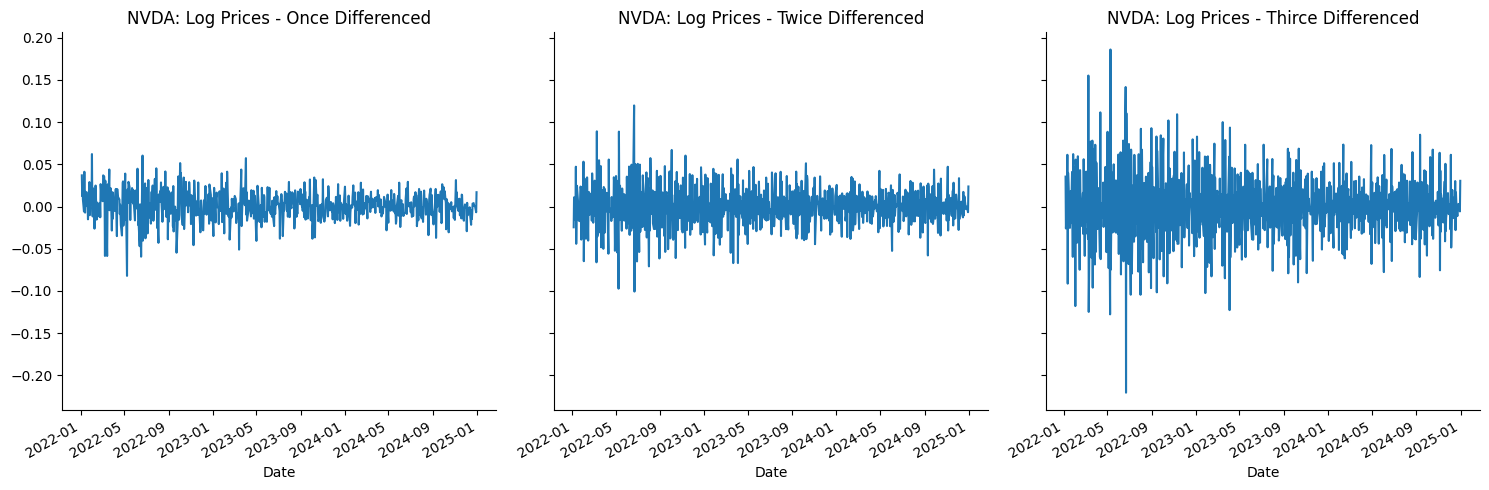

**Figure 7.** Differencing of NVDA Log Prices

In [24]:
# Plot the differenced series
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
focused_stock = 'NVDA'

# Original log returns
close_log_df1[stock].plot(ax=axes[0], title=f'{focused_stock}: Log Prices - Once Differenced')
# 2nd difference
close_log_df1[stock].diff().plot(ax=axes[1], title=f'{focused_stock}: Log Prices - Twice Differenced')
# 3rd difference
close_log_df1[stock].diff().diff().plot(ax=axes[2], title=f'{focused_stock}: Log Prices - Thirce Differenced')

for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
plt.tight_layout()
plt.show()

display(Markdown("**Figure 7.** Differencing of NVDA Log Prices"))

From Figure 8, all stocks exhibit minimal autocorrelation after first-order differencing, indicating that past values do not significantly predict future values. Consequently, the optimal autoregressive order $p$ is set to 0.

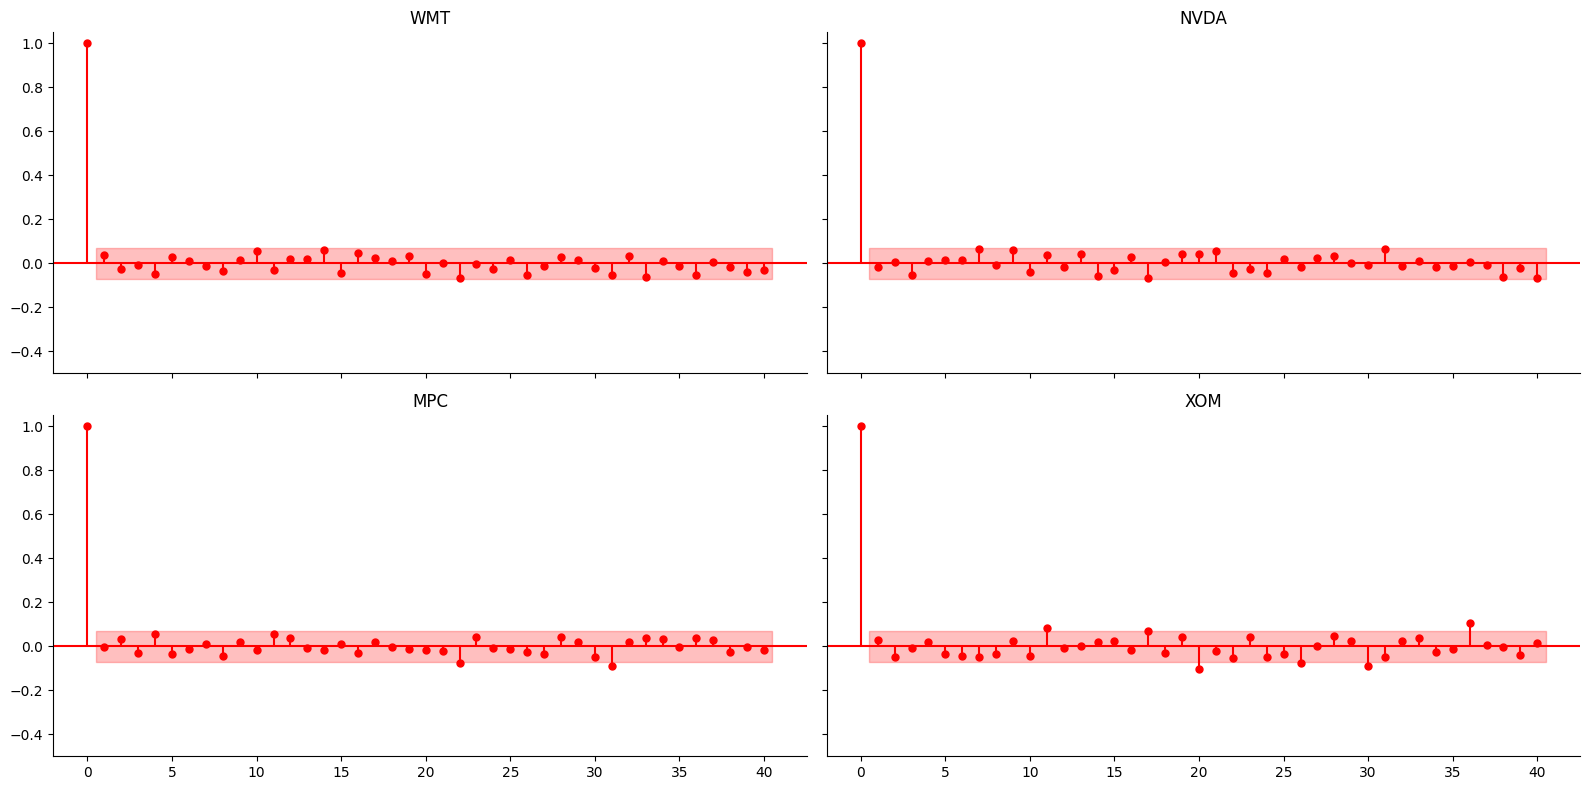

**Figure 8.** PACF of the Differenced Log Prices Across the Four Stocks

In [25]:
# Assuming close_log_df1 is your differenced data
fig, axs = plt.subplots(2, 2, figsize=(16, 8), sharex=True, sharey=True)

for ax, stock in zip(axs.flatten(), close_log_df1.columns):
    # Plot PACF
    plot_pacf(close_log_df1[stock].dropna(), ax=ax, lags=40, method='ywm')
    ax.set_title(stock)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_ylim(-0.5, 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for item in ax.collections:
        item.set_color('red')
    for item in ax.lines:
        item.set_color('red')


# Add main title
#fig.suptitle('PACF of the Differenced 30 Stocks', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

display(Markdown("**Figure 8.** PACF of the Differenced Log Prices Across the Four Stocks"))

As shown in Figure 9, most stocks exhibit minimal autocorrelation after first-order differencing, suggesting limited moving average effects. Consequently, the optimal moving average order $q$ is set to 0.

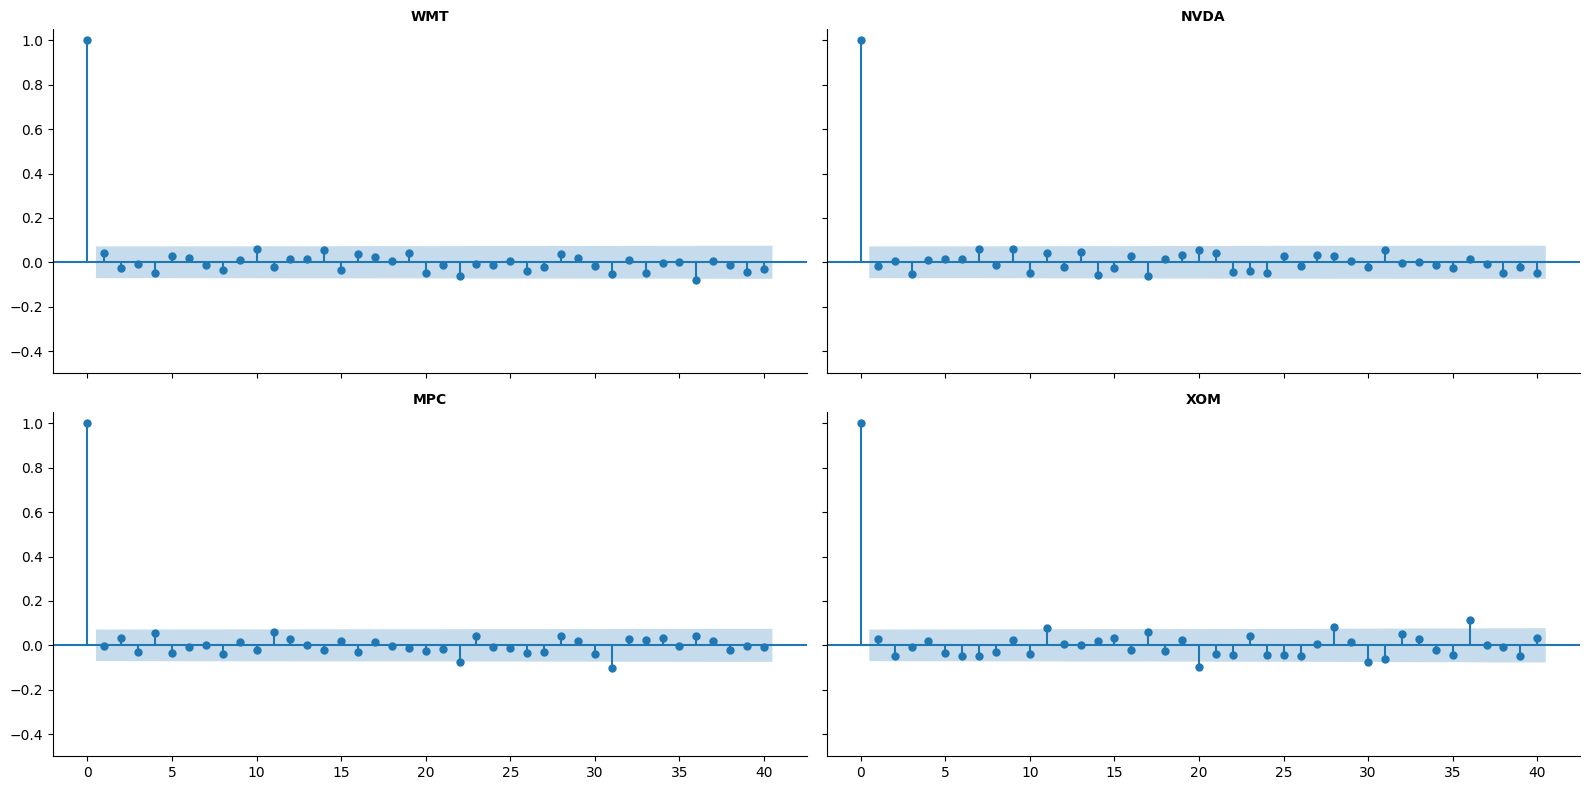

**Figure 9.** ACF of the Differenced Log Prices Across the Four Stocks

In [26]:
# Assuming close_log_df1 is your differenced data
fig, axs = plt.subplots(2, 2, figsize=(16, 8), sharex=True, sharey=True)

for ax, stock in zip(axs.flatten(), close_log_df1.columns):
    # Plot ACF
    plot_acf(close_log_df1[stock].dropna(), ax=ax, lags=40)
    ax.set_title(stock, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_ylim(-0.5, 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Add main title
#fig.suptitle('ACF of the Differenced 4 Stocks', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


display(Markdown("**Figure 9.** ACF of the Differenced Log Prices Across the Four Stocks"))

As a sanity check, we evaluated all combinations of $p$ and $q$ from 0 to 4 while keeping $d = 1$ fixed. Using the Bayesian Information Criterion (BIC) as the model selection metric, we identified the optimal $(p, q)$ in Table 4 pair for each stock, where lower BIC values indicate a better fit. This additional validation step confirmed our earlier findings that the simplest specification, ARIMA(0, 1, 0), consistently performed best across the four stocks. This reinforces the conclusion that a random-walk structure with no autoregressive or moving-average components is the most appropriate model for these log price series.

In [27]:
# Store results for all stocks
all_results = []

# Test different orders for each stock
for stock in close_log_df.columns:
    results = {}
    
    for p in range(0, 4):
        for q in range(0, 4):
            try:
                model = ARIMA(close_log_df[stock], order=(p, 1, q))
                fitted = model.fit()
                results[(p, q)] = fitted.bic
            except Exception as e:
                # Skip models that fail to converge
                continue
    
    # Check if any models succeeded
    if len(results) > 0:
        best_model = min(results, key=results.get)
        all_results.append({
            'Stock': stock,
            'Optimal p': best_model[0],
            'Optimal q': best_model[1],
            'BIC': results[best_model]
        })
    else:
        all_results.append({
            'Stock': stock,
            'Optimal p': None,
            'Optimal q': None,
            'BIC': None
        })




In [28]:
# Create and display DataFrame
bic_results_df = pd.DataFrame(all_results)

display(bic_results_df)
display(Markdown("**Table 4:** Optimal ARIMA Orders by BIC:"))

,Stock,Optimal p,Optimal q,BIC
0,WMT,0,0,-4377.634795
1,NVDA,0,0,-2924.492579
2,MPC,0,0,-3717.605150
3,XOM,0,0,-3972.429538


**Table 4:** Optimal ARIMA Orders by BIC:

We then plotted out in Figure 10 on how ARIMA(0, 1, 0) would actually forecast the log prices, and it forecasted exactly like the naive baseline. In particular, it forecasts future log prices as

$$
\ln P_{t} = \ln P_{t-1} + \varepsilon_{t},
$$

where $\varepsilon_{t+1}$ is a white noise term with mean zero. This means that the best point forecast for the next period is simply yesterday’s log price, which is similar to the approach with the naive baseline where it just uses the latest possible log price.


In [29]:
def train_and_forecast_arima(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    bic_results_df: pd.DataFrame,
    horizon: int = None
) -> pd.DataFrame:
    """
    Train ARIMA(p,1,q) models using optimal p and q, then forecast the next horizon steps.
    """

    import warnings
    warnings.filterwarnings("ignore")

    if horizon is None:
        horizon = len(val_df)  # default to validation length

    # Ensure Stock is index
    bic_results_df = bic_results_df.set_index("Stock")

    # Prepare forecast container — same index as validation set
    arima_forecasts = pd.DataFrame(index=val_df.index, columns=val_df.columns)

    # Iterate through each stock
    for stock in train_df.columns:

        # Check if stock has BIC results
        if stock not in bic_results_df.index:
            print(f"Warning: No optimal orders found for {stock}. Skipping.")
            arima_forecasts[stock] = np.nan
            continue

        try:
            # Extract optimal p, q (ensure INT)
            p = int(bic_results_df.loc[stock, "Optimal p"])
            q = int(bic_results_df.loc[stock, "Optimal q"])
            order = (p, 1, q)

            # Fit ARIMA
            model = ARIMA(train_df[stock], order=order).fit()

            # Generate forecast
            forecast_obj = model.get_forecast(steps=horizon)
            forecast = forecast_obj.predicted_mean

            # Align forecast index to validation index
            forecast.index = val_df.index

            # Store
            arima_forecasts[stock] = forecast

        except Exception as e:
            print(f"Error fitting/forecasting ARIMA for {stock}: {e}")
            arima_forecasts[stock] = np.nan

    return arima_forecasts


In [30]:
# Recursive Forecast time
arima_forecasts_df = train_and_forecast_arima(
    train_df, 
    val_df, 
    bic_results_df, 
    horizon=val_df.shape[0]
)

# Add it to the performance_stock dictionary
for stock in selected_stocks:
    performance_stock[stock]['ARIMA(0, 1, 0)'] = ForecastingMetrics.compute_all_metrics(
        val_df[stock], arima_forecasts_df[stock]
    )


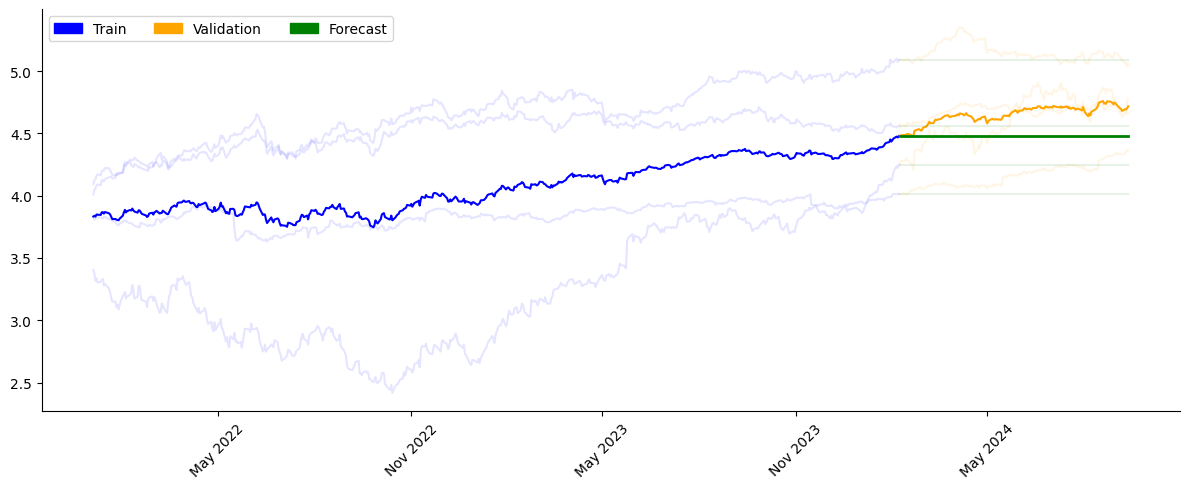

**Figure 10.** ARIMA Forecasts of Log Prices Across Stocks

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))

opacity_num = 0.1

# --- Training data ---
ax.plot(train_df, color='blue', alpha=opacity_num)
ax.plot(train_df.mean(axis=1), color='blue')

# --- Validation data ---
ax.plot(val_df, color='orange', alpha=opacity_num)
ax.plot(val_df.mean(axis=1), color='orange')

# --- ARIMA forecast ---
ax.plot(arima_forecasts_df, color='green', alpha=opacity_num, label='ARIMA Forecast')
ax.plot(arima_forecasts_df.mean(axis=1), color='green', linewidth=2, label='ARIMA Forecast Mean')

#ax.set_title('ARIMA Forecast to the Validation Set')

# Prettier x-axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

# Add patches legend at the bottom for dataset colors
train_patch = mpatches.Patch(color='blue', label='Train')
val_patch = mpatches.Patch(color='orange', label='Validation')
forecast_patch = mpatches.Patch(color='green', label='Forecast')

plt.legend(handles=[train_patch, val_patch, forecast_patch], loc='best', ncol=3)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

display(Markdown("**Figure 10.** ARIMA Forecasts of Log Prices Across Stocks"))

## c. Random Walk with Drift

Let us now extend the random walk to include a drift. Assuming there is an underlying growth in stock prices, we take the first difference of the log prices and compute the mean. This yields the mean log return ($\mu$), which can be interpreted as the drift term in the model. We write this down as:
$$\ln P_{t} = \ln P_{t-1} + \mu + \varepsilon_{t}.$$
As shown in Figure 11, this approach better captures the log prices since it follows the upward trend of the stocks.

In [33]:
# Example: train_df is log prices, columns = stocks, rows = dates
forecast_horizon = 150

# 1. Compute mean log return (drift) per stock
drift = train_df.diff().mean(axis=0)  # pandas Series, index = stocks

# 2. Get last log price per stock
last_log_price = train_df.iloc[-1]   # Series, index = stocks

# 3. Create random walk with drift
# For simplicity, here we just add the drift deterministically (no noise)
forecast_log_prices = pd.DataFrame(
    index=val_df.index, 
    columns=train_df.columns,
    dtype=float
)

for stock in train_df.columns:
    # Add drift cumulatively
    forecast_log_prices[stock] = last_log_price[stock] + np.cumsum(np.repeat(drift[stock], forecast_horizon))

# Get the performance
for stock in selected_stocks:
    performance_stock[stock]['Random Wak with Drift'] = ForecastingMetrics.compute_all_metrics(
        val_df[stock], forecast_log_prices[stock]
    )

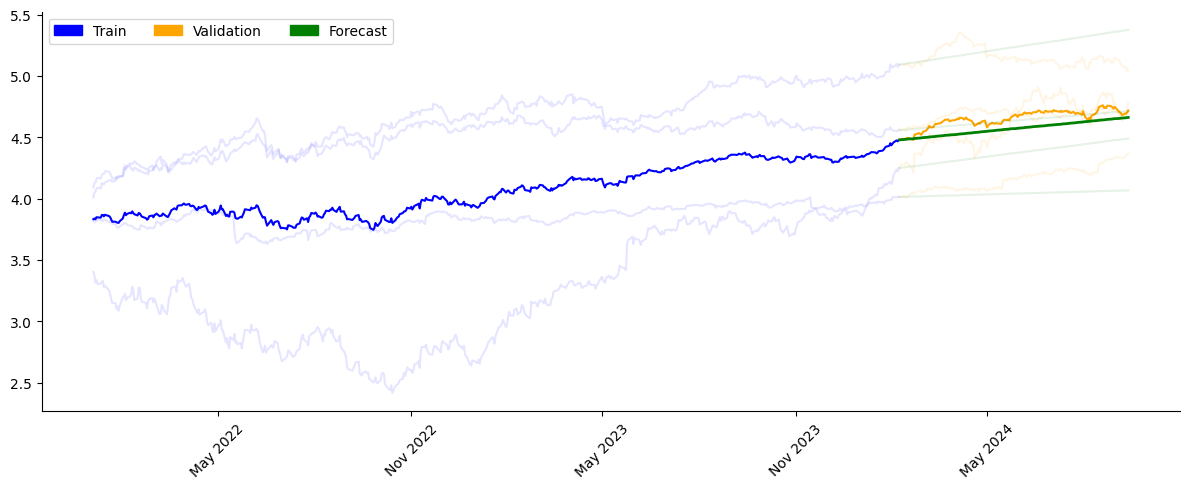

**Figure 11.** Random Walk with Drift Forecasts of Log Prices Across Stocks

In [34]:
fig, ax = plt.subplots(figsize=(12, 5))

opacity_num = 0.1

# --- Training data ---
ax.plot(train_df, color='blue', alpha=opacity_num)
ax.plot(train_df.mean(axis=1), color='blue')

# --- Validation data ---
ax.plot(val_df, color='orange', alpha=opacity_num)
ax.plot(val_df.mean(axis=1), color='orange')

# --- ARIMA forecast ---
ax.plot(forecast_log_prices, color='green', alpha=opacity_num, label='ARIMA Forecast')
ax.plot(forecast_log_prices.mean(axis=1), color='green', linewidth=2, label='ARIMA Forecast Mean')

#ax.set_title('Random Walk with Drift Forecast to the Validation Set')

# Prettier x-axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

# Add patches legend at the bottom for dataset colors
train_patch = mpatches.Patch(color='blue', label='Train')
val_patch = mpatches.Patch(color='orange', label='Validation')
forecast_patch = mpatches.Patch(color='green', label='Forecast')

plt.legend(handles=[train_patch, val_patch, forecast_patch], loc='best', ncol=3)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

display(Markdown("**Figure 11.** Random Walk with Drift Forecasts of Log Prices Across Stocks"))

## d. ML Models (Ridge and Random Forest)

In addition to the current models we have, we also included standard machine learning models such as Random Forest, XGBoost, Linear Regression, Ridge Regression, and Gradient Boosting. Linear regression was used as a simple, interpretable benchmark for predicting linear relationships between the predictors and returns. Ridge regression extends this by adding regularization to reduce overfitting if features are correlated. Random Forest was selected as its ensemble structure captures nonlinear relationship effects between variables to make it robust to noise and overfitting. Gradient Boosting and XGBoost were included because boosting methods reduce residual errors, achieving high predictive accuracy in settings where patterns are subtle or complex. These models complement the econometric approaches by providing non-linear estimators that can potentially capture intricate dynamics in asset prices that traditional time-series models may miss.


In [36]:
# helper functions given by prof
def train_test_split(
    data: pd.Series, lookback: int = 12, test_size: int = 12
) -> Tuple[pd.Series, pd.Series]:
    """Create a train-test split on your pd.Series data.

    Parameters:
    -----------
    data (pd.Series): The univariate time series provided
    lookback (int): The lookback periods to consider
    test_size (int): The length of the test set

    Returns:
    --------
    Tuple (pd.Series): The (train, test) pandas series generated
    """

    split = data.shape[0] - test_size
    return (data.iloc[:split], data.iloc[split - lookback :])


def create_xy(
    series: pd.Series, lookback: int = 12, horizon: int = 1
) -> Tuple[np.ndarray, np.ndarray]:
    """Create the X and y arrays from a pd.Series object. The `lookback`
    determines the number of features we would include in X. While the
    `horizon` paramter informs us how many points we'll need to forecast.

    Paramters:
    ----------
    series (pd.Series): the (n, 1) time series to be sliced into X and Y
    lookback (int): the lookback window to consider (default=12)
    horizon (int): the number of points to forecast for each row in X (default=1)

    Returns:
    -------
    (X, y) (Tuple): a tuple of ndarrays
    """
    x = []
    y = []

    series_size = series.shape[0]
    for i in range(series_size):

        # break loop if series is less than the required time horizon
        if series.iloc[(i + lookback) : (i + lookback + horizon)].shape[0] < horizon:
            break
        x.append(series.iloc[i : (i + lookback)])
        y.append(series.iloc[(i + lookback) : (i + lookback + horizon)])
    x = np.dstack(x)
    y = np.dstack(y)

    # Reshape x to (samples, features, lookback)
    x = np.swapaxes(x, 0, 2)
    # Then flatten (samples, features * lookback)
    x = x.reshape(x.shape[0], x.shape[1] * x.shape[2])

    # Reshape y tp (samples, horizon)
    y = np.swapaxes(y, 0, 2)
    y = y[:, :, 0]

    return x, y

In [39]:
# Example hyperparameters
lookbacks = [1, 3, 5, 7, 20]
ridge_alphas = [0.01, 1]
rf_n_trees = [100, 300, 500]
tscv = TimeSeriesSplit(n_splits=5)

# To store results
ridge_best_per_stock = {}
rf_best_per_stock = {}

# Loop over stocks
for stock in selected_stocks:
    # univariate series and difference to get log returns
    series = train_df[stock].diff().dropna().reset_index(drop=True) 
    best_ridge_mse = np.inf
    best_rf_mse = np.inf

    # for each lookback, create the X and y
    for lb in lookbacks:
        X, y = create_xy(series, lookback=lb, horizon=1)
        y = y.ravel()

        # Ridge regression
        for alpha in ridge_alphas:
            # val_results is a list that contains dictionaries from ForecastingMetrics.compute_all_metrics
            val_results = []
            for train_idx, val_idx in tscv.split(X):
                X_train_tmp, y_train_tmp = X[train_idx], y[train_idx]
                X_val_tmp, y_val_tmp = X[val_idx], y[val_idx]

                model = Ridge(alpha=alpha)
                model.fit(X_train_tmp, y_train_tmp)
                val_preds = model.predict(X_val_tmp)
                val_results.append(ForecastingMetrics.compute_all_metrics(y_val_tmp, val_preds))

            # Aggregate metrics from val_results
            aggregated_metrics = {name: np.mean([fold[name] for fold in val_results])
                                  for name in ['MAE','MSE','RMSE','MAPE','SMAPE','Directional Accuracy']}
            
            # make our lives simpler and just prioritize on MSE
            if aggregated_metrics['MSE'] < best_ridge_mse:
                best_ridge_mse = aggregated_metrics['MSE']
                ridge_best_per_stock[stock] = {"lookback": lb, "alpha": alpha, "metrics": aggregated_metrics}

        # Random Forest
        # similar but now on random forest
        for n in rf_n_trees:
            val_results = []
            for train_idx, val_idx in tscv.split(X):
                X_train_tmp, y_train_tmp = X[train_idx], y[train_idx]
                X_val_tmp, y_val_tmp = X[val_idx], y[val_idx]

                model = RandomForestRegressor(n_estimators=n, random_state=42)
                model.fit(X_train_tmp, y_train_tmp)
                val_preds = model.predict(X_val_tmp)
                val_results.append(ForecastingMetrics.compute_all_metrics(y_val_tmp, val_preds))

            aggregated_metrics = {name: np.mean([fold[name] for fold in val_results])
                                  for name in ['MAE','MSE','RMSE','MAPE','SMAPE','Directional Accuracy']}
            
            if aggregated_metrics['MSE'] < best_rf_mse:
                best_rf_mse = aggregated_metrics['MSE']
                rf_best_per_stock[stock] = {"lookback": lb, "n_estimators": n, "metrics": aggregated_metrics}


In [41]:
# given what we have found to be the best parameters from the train set, let's go to the validation
n = close_log_df.shape[0]
train_end = int(n * 0.7)
val_end = train_end + int(n * 0.2)
val_points = val_end - train_end

# for the actual forecasts
lr_preds_per_stock = {}
rf_preds_per_stock = {}

# the non_test is just the train and val (so all that is not test)
non_test_df = close_log_df.iloc[:val_end]

for stock in selected_stocks:
    # --- Ridge ---
    best_params = ridge_best_per_stock[stock]
    lb, alpha = best_params["lookback"], best_params["alpha"]

    # Split train/val and difference it so that it is stationary
    train_series, val_series = train_test_split(non_test_df[stock].diff().dropna(), lookback=lb, test_size=val_points)

    # Create the Design matrices
    X_train, y_train = create_xy(train_series.reset_index(drop=True), lookback=lb)
    X_val, y_val = create_xy(val_series.reset_index(drop=True), lookback=lb)
    y_train, y_val = y_train.ravel(), y_val.ravel()

    # Fit
    model_lr = Ridge(alpha=alpha)
    model_lr.fit(X_train, y_train)
    val_preds_diff = model_lr.predict(X_val)

    # so that we can compare apples to apples, make sure that we are recursively forecasting
    # this is NOT a point forecast
    last_price = non_test_df[stock].iloc[train_end-1]

    # recall we were predicting on the log returns
    # we need to get the price forecast back
    price_forecast = np.empty_like(val_preds_diff)
    price_forecast[0] = last_price + val_preds_diff[0]
    for t in range(1, len(val_preds_diff)):
        price_forecast[t] = price_forecast[t-1] + val_preds_diff[t]

    lr_preds_per_stock[stock] = price_forecast
    performance_stock[stock]['Linear Regression'] = ForecastingMetrics.compute_all_metrics(
        non_test_df[stock].iloc[train_end:val_end].values, price_forecast
    )

    # --- Random Forest ---
    # the same but on the random forest
    best_params_rf = rf_best_per_stock[stock]
    lb_rf, n_trees = best_params_rf["lookback"], best_params_rf["n_estimators"]

    train_series_rf, val_series_rf = train_test_split(non_test_df[stock].diff().dropna(), lookback=lb_rf, test_size=val_points)
    X_train_rf, y_train_rf = create_xy(train_series_rf.reset_index(drop=True), lookback=lb_rf, horizon=1)
    X_val_rf, y_val_rf = create_xy(val_series_rf.reset_index(drop=True), lookback=lb_rf, horizon=1)
    y_train_rf, y_val_rf = y_train_rf.ravel(), y_val_rf.ravel()

    model_rf = RandomForestRegressor(n_estimators=n_trees, random_state=42)
    model_rf.fit(X_train_rf, y_train_rf)
    val_preds_diff_rf = model_rf.predict(X_val_rf)

    # Recursive reconstruction
    last_price_rf = non_test_df[stock].iloc[train_end-1]
    price_forecast_rf = np.empty_like(val_preds_diff_rf)
    price_forecast_rf[0] = last_price_rf + val_preds_diff_rf[0]
    for t in range(1, len(val_preds_diff_rf)):
        price_forecast_rf[t] = price_forecast_rf[t-1] + val_preds_diff_rf[t]

    rf_preds_per_stock[stock] = price_forecast_rf
    performance_stock[stock]['Random Forest'] = ForecastingMetrics.compute_all_metrics(
        non_test_df[stock].iloc[train_end:val_end].values, price_forecast_rf
    )


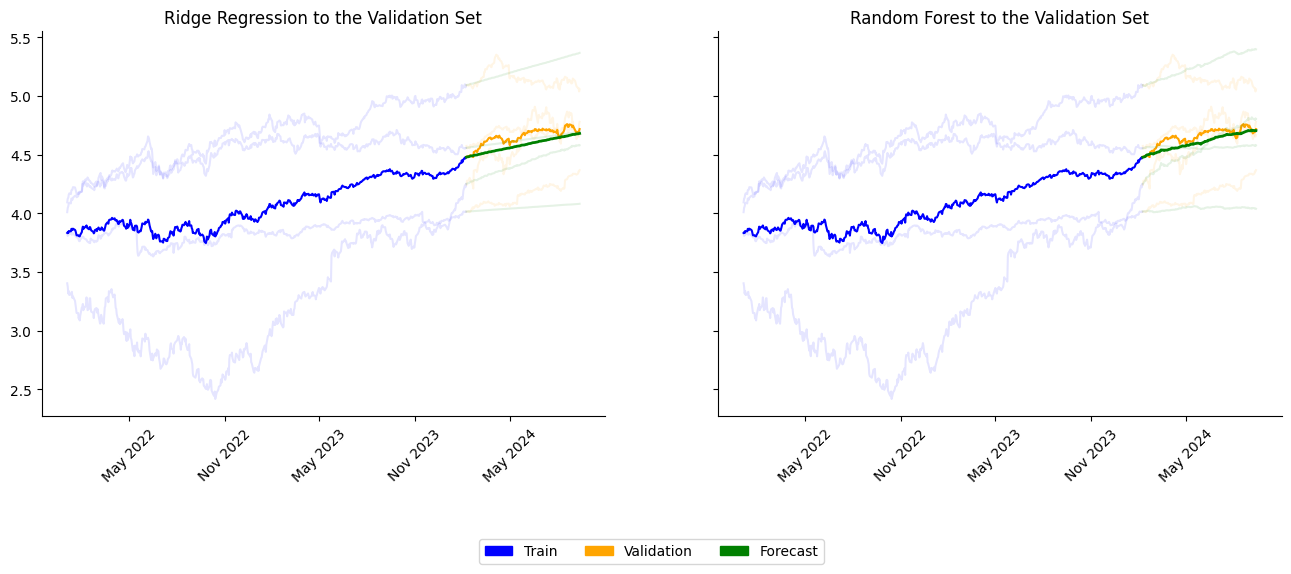

**Figure 12.** Baseline Forecasts of Log Prices Across Stocks

In [42]:
lr_preds_per_stock_df = pd.DataFrame(lr_preds_per_stock)
lr_preds_per_stock_df.index = val_df.index

rf_preds_per_stock_df = pd.DataFrame(rf_preds_per_stock)
rf_preds_per_stock_df.index = val_df.index

# Drawing time!
fig, axs = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)

opacity_num = 0.1
for ax in axs:
    ax.plot(train_df, color='blue', alpha=opacity_num)
    ax.plot(train_df.mean(axis=1), color='blue')

    ax.plot(val_df, color='orange', alpha=opacity_num)
    ax.plot(val_df.mean(axis=1), color='orange', label='Val Median')

# Plot the mean
axs[0].plot(lr_preds_per_stock_df, label='Ridge Regression', color='green', alpha=opacity_num)
axs[0].plot(lr_preds_per_stock_df.mean(axis=1), label='Ridge Regression', linewidth=2, color='green')
axs[0].set_title('Ridge Regression to the Validation Set')

# plot the naive
axs[1].plot(rf_preds_per_stock_df, label='Random Forest', color='green', alpha=opacity_num)
axs[1].plot(rf_preds_per_stock_df.mean(axis=1), label='Random Forest', linewidth=2, color='green')
axs[1].set_title('Random Forest to the Validation Set')

# Prettier x-axis
for ax in axs:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # major ticks each month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # format as 'Jan 2025'
    ax.tick_params(axis='x', rotation=45)  # rotate labels
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# Add patches legend at the bottom for dataset colors
train_patch = mpatches.Patch(color='blue', label='Train')
val_patch = mpatches.Patch(color='orange', label='Validation')
forecast_patch = mpatches.Patch(color='green', label='Forecast')

plt.legend(handles=[train_patch, val_patch, forecast_patch], loc='best', bbox_to_anchor=(0.2, -0.3), ncol=3)

plt.show()

display(Markdown("**Figure 12.** Baseline Forecasts of Log Prices Across Stocks"))


## e. Methodology study of Ślusarczyk and Ślepaczuk

In addition to our current traditional models, we also implemented a hybrid ARIMA / ARIMA-GARCH procedure inspired by Algorithm 1 in Ślusarczyk & Ślepaczuk (2025). As seen from the image, we first fit an ARIMA(2,1,1) model to the historical log-returns and apply an ARCH-LM test to detect volatility clustering. The null hypothesis of this test is that the residuals exhibit no ARCH effects (i.e., they are homoscedastic). If the test indicates significant ARCH effects, we keep the ARIMA forecast but if not we estimate a GARCH(1,1) model on the ARIMA residuals and bootstrap future residuals. These simulated innovations are added to the ARIMA mean forecast, and the final prediction is the average of the simulation runs. If a model fails to converge, we fall back to the standard ARIMA forecast. 


In [40]:
pip install statsmodels arch tqdm

Note: you may need to restart the kernel to use updated packages.


In [43]:
# --- Use the currently defined variables ---
# train_df, val_df, test_df are already defined (70/20/10 split)
# Just assign log returns if needed (they are already log returns if close_log_df was used)
logret_train = train_df.copy()
logret_val = val_df.copy()
logret_test = test_df.copy()

print(f"Training set: {train_df.shape[0]} rows ({train_df.shape[0]/(train_df.shape[0]+val_df.shape[0]+test_df.shape[0]):.0%})")
print(f"Validation set: {val_df.shape[0]} rows ({val_df.shape[0]/(train_df.shape[0]+val_df.shape[0]+test_df.shape[0]):.0%})")
print(f"Test set: {test_df.shape[0]} rows ({test_df.shape[0]/(train_df.shape[0]+val_df.shape[0]+test_df.shape[0]):.0%})")


Training set: 527 rows (70%)
Validation set: 150 rows (20%)
Test set: 76 rows (10%)


In [45]:
# Dictionaries to store forecasts and methods
arima_forecasts = {}
method_used = {}

Tf = len(val_df)  # forecast horizon = validation period

# Fixed RNG for reproducibility (important!)
rng = np.random.default_rng(42)

# Forecast loop per stock
for stock in selected_stocks:
    r = train_df[stock].dropna()
    
    if len(r) < 20:
        arima_forecasts[stock] = np.zeros(Tf)
        method_used[stock] = "Skipped (not enough data)"
        continue

    # ARCH test
    try:
        stat, pval, _, _ = het_arch(r, nlags=5)
    except:
        pval = 1.0

    # Forecast
    order_by_god = (2,1,1)
    if pval < 0.05:  # reject H0 → ARIMA only
        try:
            arima_res = ARIMA(r, order=order_by_god).fit()
            arima_forecasts[stock] = arima_res.get_forecast(Tf).predicted_mean.values
            method_used[stock] = "ARIMA"
        except:
            arima_forecasts[stock] = np.zeros(Tf)
            method_used[stock] = "ARIMA (failed)"
    else:  # H0 not rejected → ARIMA-GARCH (deterministic simulation)
        try:
            arima_res = ARIMA(r, order=order_by_god).fit()
            arima_mean = arima_res.get_forecast(Tf).predicted_mean.values

            garch_mod = arch_model(arima_res.resid, p=1, q=1, mean='Zero')
            garch_res = garch_mod.fit(disp="off")

            # Deterministic simulation using fixed RNG
            sim = garch_res.simulate(
                garch_res.params,
                nobs=Tf,
                repetitions=50,
                rng=rng
            )
            sim_resid = sim["data"]

            arima_forecasts[stock] = (arima_mean[:, None] + sim_resid).mean(axis=1)
            method_used[stock] = "ARIMA-GARCH"
        except:
            try:
                fallback = ARIMA(r, order=order_by_god).fit()
                arima_forecasts[stock] = fallback.get_forecast(Tf).predicted_mean.values
                method_used[stock] = "ARIMA (fallback)"
            except:
                arima_forecasts[stock] = np.zeros(Tf)
                method_used[stock] = "Failed"

# Convert forecasts to DataFrame
arima_forecasts_df = pd.DataFrame(arima_forecasts, index=val_df.index)

# Compute metrics and append to existing performance_stock
for stock in selected_stocks:
    performance_stock[stock]['ARIMA/ARIMA-GARCH'] = ForecastingMetrics.compute_all_metrics(
        val_df[stock], arima_forecasts_df[stock]
    )

## f. VAR

Vector Autoregression (VAR) is a model that captures linear interdependencies among multiple time series. VAR models each variable as a linear function of its own lagged values and the lagged values of all other variables in the system. This makes it useful for analyzing how shocks in one variable can affect others over time. These models are often applied in economics finance for forecasting which makes it appropriate for our case (Jimoh, 2023). Overall, VAR could help further improve our study by providing a flexible framework to model complex interactions in multivariate time series data. 

In [49]:
# Get again the dataframes for this
all_log_df = np.log(yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"])
all_train_df = all_log_df.iloc[:train_end]

# we minus one because we will difference
all_val_df = all_log_df.iloc[train_end - 1:val_end]
all_test_df = all_log_df.iloc[val_end - 1:]


[*********************100%***********************]  30 of 30 completed


In [50]:
log_returns_train = all_train_df.diff().dropna()
log_returns_val = all_val_df.diff().dropna()

# Dictionaries to store forecasts
var_forecasts = {}
var_methods = {}

for stock in selected_stocks:
    # Find related stocks in the same category
    related_stocks = category_stock[stock_categories[stock]]

    # Select returns for training and validation
    related_returns_train = log_returns_train[related_stocks]
    related_returns_val = log_returns_val[related_stocks]

    # Fit VAR on related returns
    model = VAR(related_returns_train)
    lag_selection = model.select_order(maxlags=5)
    best_lag = lag_selection.selected_orders['aic']
    print(f"Selected lag order (AIC) for {stock}: {best_lag}")

    var_res = model.fit(best_lag)

    # Forecast returns for validation period
    if best_lag == 0:
        # Predict mean return for all steps
        mean_return = related_returns_train.mean()
        forecast_returns = np.tile(mean_return.values, (len(related_returns_val), 1))
    else:
        forecast_returns = var_res.forecast(
            related_returns_train.values[-best_lag:], 
            steps=len(related_returns_val)
        )

    forecast_returns_df = pd.DataFrame(
        forecast_returns,
        index=related_returns_val.index,
        columns=related_returns_train.columns
    )

    # Convert forecasted returns back to log prices
    last_log_price = all_train_df[stock].iloc[-1]
    adjusted_all_val_df = all_val_df.iloc[1:]
    forecast_log_price = last_log_price + np.cumsum(forecast_returns_df[stock])

    # Save forecast
    var_forecasts[stock] = forecast_log_price

    # Save **only the target stock** forecast
    var_forecasted = forecast_returns_df[stock]
    performance_stock[stock][f'VAR ({best_lag})'] = ForecastingMetrics.compute_all_metrics(
    adjusted_all_val_df[stock], forecast_log_price
)

Selected lag order (AIC) for WMT: 0
Selected lag order (AIC) for NVDA: 0
Selected lag order (AIC) for MPC: 1
Selected lag order (AIC) for XOM: 1


In [51]:
metrics_df_selected = performance_dict_to_df(performance_stock)

# Display metrics per stock sorted by MSE (smallest to largest)
for stock in selected_stocks:
    print(f"Metrics for {stock} (sorted by MSE):")
    stock_metrics = metrics_df_selected.loc[stock].sort_values(by='MSE')
    display(stock_metrics)
    print("-" * 60)

Metrics for WMT (sorted by MSE):


,MAE,MSE,RMSE,MAPE,SMAPE,Directional Accuracy
Model,,,,,,
Linear Regression,0.112272,0.018224,0.134997,2.660466,2.711905,57.046978
Random Wak with Drift,0.118807,0.020245,0.142284,2.815797,2.873026,57.046978
VAR (0),0.118807,0.020245,0.142284,2.815797,2.873026,57.046978
Random Forest,0.120411,0.021883,0.147931,2.850743,2.912556,46.308723
Naive,0.145786,0.029891,0.172891,3.456762,3.541766,42.953022
"ARIMA(0, 1, 0)",0.145786,0.029891,0.172891,3.456762,3.541766,42.953022
ARIMA/ARIMA-GARCH,0.146032,0.029967,0.173110,3.462672,3.547899,46.308723
Seasonal Naive,0.177148,0.040336,0.200838,4.211177,4.326818,48.993290
Mean,0.309011,0.104154,0.322728,7.382480,7.689179,42.953022


------------------------------------------------------------
Metrics for NVDA (sorted by MSE):


,MAE,MSE,RMSE,MAPE,SMAPE,Directional Accuracy
Model,,,,,,
Random Forest,0.089415,0.013009,0.114055,1.906067,1.926603,44.966442
Linear Regression,0.190154,0.049012,0.221386,4.040650,4.151879,46.308723
Random Wak with Drift,0.244972,0.077186,0.277823,5.208630,5.385542,54.362415
VAR (0),0.244972,0.077186,0.277823,5.208630,5.385542,54.362415
ARIMA/ARIMA-GARCH,0.365603,0.167068,0.408740,7.775921,8.166244,44.295303
Naive,0.366027,0.167392,0.409136,7.785086,8.176199,45.637585
"ARIMA(0, 1, 0)",0.366027,0.167392,0.409136,7.785086,8.176199,45.637585
Seasonal Naive,0.511087,0.297947,0.545845,10.938992,11.655951,47.651009
Mean,1.355541,1.871434,1.368004,29.260727,34.340237,45.637585


------------------------------------------------------------
Metrics for MPC (sorted by MSE):


,MAE,MSE,RMSE,MAPE,SMAPE,Directional Accuracy
Model,,,,,,
Naive,0.066385,0.008824,0.093935,1.271639,1.287487,46.308723
"ARIMA(0, 1, 0)",0.066385,0.008824,0.093935,1.271639,1.287487,46.308723
ARIMA/ARIMA-GARCH,0.066620,0.008866,0.094159,1.276184,1.292118,50.335571
Seasonal Naive,0.123777,0.021508,0.146655,2.385125,2.425303,48.993290
VAR (1),0.126881,0.022232,0.149102,2.467901,2.437014,53.691277
Linear Regression,0.127984,0.022612,0.150372,2.489637,2.457837,53.691277
Random Wak with Drift,0.130874,0.023743,0.154087,2.546483,2.512108,53.691277
Random Forest,0.149955,0.031695,0.178032,2.920504,2.870300,48.322147
Mean,0.491423,0.246697,0.496686,9.522042,10.007131,46.308723


------------------------------------------------------------
Metrics for XOM (sorted by MSE):


,MAE,MSE,RMSE,MAPE,SMAPE,Directional Accuracy
Model,,,,,,
Random Wak with Drift,0.049045,0.003953,0.062875,1.043503,1.052180,51.677853
VAR (1),0.051750,0.004213,0.064907,1.100912,1.110302,51.677853
Linear Regression,0.057177,0.004840,0.069573,1.216386,1.227308,51.677853
Random Forest,0.117823,0.016026,0.126596,2.507486,2.544229,54.362415
Naive,0.123647,0.017429,0.132018,2.631741,2.671728,48.322147
"ARIMA(0, 1, 0)",0.123647,0.017429,0.132018,2.631741,2.671728,48.322147
ARIMA/ARIMA-GARCH,0.123982,0.017514,0.132341,2.638904,2.679089,48.322147
Seasonal Naive,0.144165,0.023349,0.152804,3.070589,3.124379,50.335571
Mean,0.184296,0.036134,0.190090,3.927441,4.011040,48.322147


------------------------------------------------------------


The table below summarizes the insights from the performance of the models for each stock and identifies the most suitable forecasting model based on the evaluation metrics.

| **Stock** | **Findings** | **Final Model** |
|-----------|--------------|-----------------|
| **WMT** | • Linear Regression dominates with the lowest MSE and best error metrics, indicating largely linear and predictable price dynamics.<br>• Random Walk with Drift and VAR(0) perform similarly but worse than Linear Regression, showing limited value from drift or multivariate components.<br>• Tree-based methods underperform, suggesting little nonlinear structure in WMT prices. | **Ridge Regression** |
| **NVDA** | • Random Forest is the best model, outperforming all others across MSE, RMSE, and MAE, indicating strong nonlinear patterns in NVDA’s price movements.<br>• Linear Regression performs poorly, meaning NVDA’s high volatility isn't captured by a linear structure.<br>• ARIMA-based models fail due to NVDA’s explosive growth and structural breaks. | **Random Forest** |
| **MPC** | • Naive and ARIMA(0,1,0) produce the lowest errors, implying MPC follows a near–random walk process.<br>• VAR(1) and Linear Regression improve directional accuracy but still perform worse than Random Walk models in terms of errors.<br>• Random Forest and nonlinear models worsen performance, showing no strong nonlinear dependencies. | **ARIMA(0,1,0)** |
| **XOM** | • Random Walk with Drift is the best performer with the lowest MSE, consistent with stable commodity-linked stock behavior.<br>• VAR(1) and Linear Regression are competitive but do not surpass Random Walk with Drift.<br>• Tree-based models perform worst, confirming XOM follows a stable stochastic process rather than nonlinear patterns. | **Random Walk with Drift** |


**Table 8:** Model Selection Summary Based on Forecasting Performance

# VI. Re-optimize the portfolio using the Forecasted Prices

Traditional Markowitz portfolio optimization is static because it relies solely on historical averages and covariances. To enhance the responsiveness of the portfolio to changing market conditions, we extend the framework in two major ways by incorporating forecasted returns into mean-variance optimization and by adding a time-series momentum overlay. This extension draws motivation from the approaches outlined in Ślusarczyk and Ślepaczuk (2025) and Shi (2025), who respectively demonstrate how integrating predictive signals and trend-following rules can improve the adaptability of classical portfolio models.

For the first step, we introduce a forward-looking component by complementing the historical mean returns and covariance by adding the forecasted returns and covariance, which came from the best models that were found in Table 8. Effectively, for each asset $j$, we form a 120-day return sequence composed of the most recent 60 actual log returns and the next 60 model-forecasted log returns obtained from the best-performing predictive models identified in Table 8. We thus have:


$$
\mu^* =
\begin{bmatrix}
\mu_1^* \\
\vdots \\
\mu_n^*
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{T} \sum_{i=1}^T r_{t-i,1}^* \\
\vdots \\
\frac{1}{T} \sum_{i=1}^T r_{t-i,n}^*
\end{bmatrix}.
$$

where on the test day such as January 1, 2025, the expected log returns would average over the 60 days prior and the 60 days forecasted. Similarly, the variance–covariance matrix of the historical and forecasted log returns is:


$$
\Sigma^* =
\begin{bmatrix}
\sigma_{1}^{*2} & \cdots & \sigma_{1n}^* \\
\vdots & \ddots & \vdots \\
\sigma_{n1}^* & \cdots & \sigma_{n}^{*2}
\end{bmatrix},
$$


where:


- $\sigma_i^{*2}$ is the empirical variance of the actual and forecasted log returns of the $i$-th asset, and 
- $\sigma_{ij}^*$ is the empirical covariance between the actual and forecasted log returns of assets $i$ and $j$.


The resulting expected return vector $\mu^*$ and covariance matrix $\Sigma^*$ allow the model to remain within the classical mean–variance framework while becoming more responsive to short-term forecasted dynamics.
